Dataset shape: (891, 5)

Pclass vs Survived contingency table:
Survived    0    1
Pclass            
1          80  136
2          97   87
3         372  119

=== CHI-SQUARE TEST ===
Chi-square statistic: 102.8890
p-value: 0.0000
Degrees of freedom: 2
Expected frequencies:
 [[133.1  82.9]
 [113.4  70.6]
 [302.5 188.5]]
REJECT H0: Significant association between Pclass and Survived

=== WILCOXON SIGNED-RANK TEST ===
Test statistic (W): 127627.5000
p-value: 1.0000
Fail to reject H0: Median Age unchanged by imputation


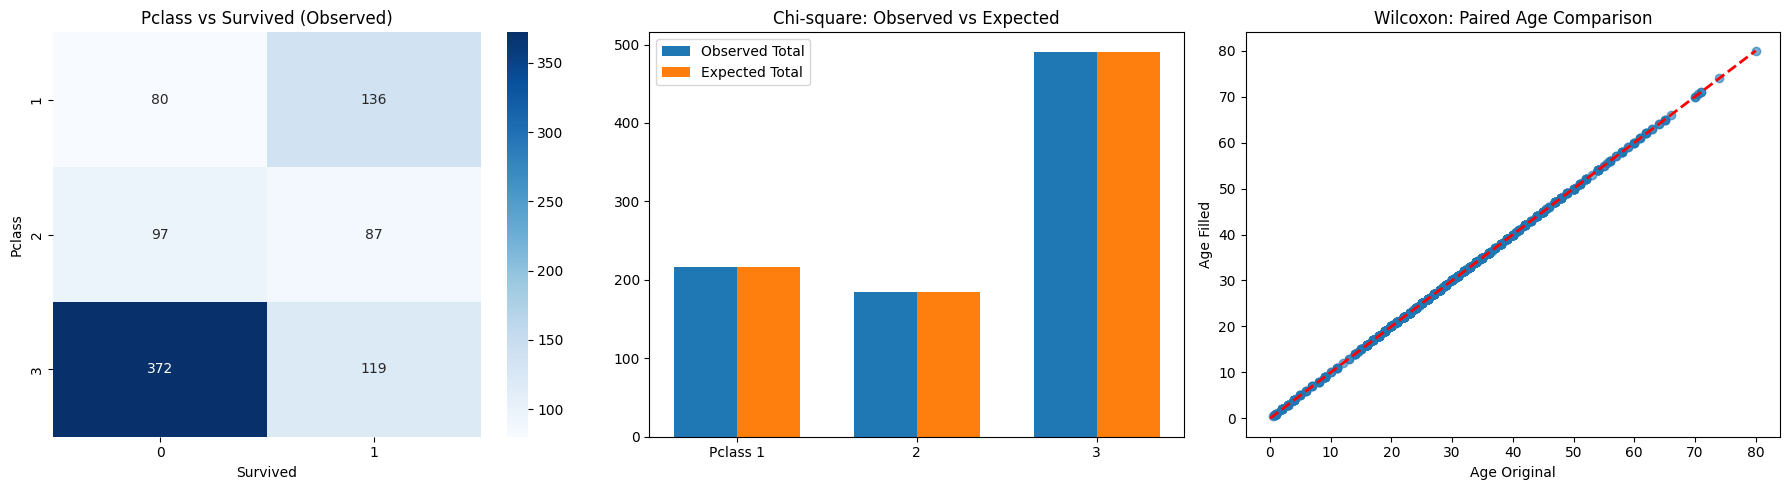

In [9]:
# Data Science Lab Assignment 3: Non-Parametric Hypothesis Tests
# Dataset: Preprocessed Titanic (from Assignment 1)

import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, wilcoxon
import seaborn as sns
import matplotlib.pyplot as plt

# Load & preprocess
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
df['Age_filled'] = df.groupby(['Pclass','Sex'])['Age'].transform(lambda x: x.fillna(x.median()))
df_clean = df[['Survived', 'Pclass', 'Sex', 'Age', 'Age_filled']].copy()

print("Dataset shape:", df_clean.shape)
print("\nPclass vs Survived contingency table:")
contingency = pd.crosstab(df_clean['Pclass'], df_clean['Survived'])
print(contingency)

# CHI-SQUARE TEST OF INDEPENDENCE (Pclass vs Survived)
print("\n=== CHI-SQUARE TEST ===")
chi2, p_chi, dof, expected = chi2_contingency(contingency)
print(f"Chi-square statistic: {chi2:.4f}")
print(f"p-value: {p_chi:.4f}")
print(f"Degrees of freedom: {dof}")
print("Expected frequencies:\n", np.round(expected, 1))

alpha = 0.05
if p_chi < alpha:
    print("REJECT H0: Significant association between Pclass and Survived")
else:
    print("Fail to reject H0: No association")

# WILCOXON SIGNED-RANK TEST (Age before/after imputation, non-missing only)
print("\n=== WILCOXON SIGNED-RANK TEST ===")
mask = df['Age'].notna()
age_original = df.loc[mask, 'Age'].values
age_filled_all = df.loc[mask, 'Age_filled'].values
statistic, p_wilcox = wilcoxon(age_original, age_filled_all, zero_method='zsplit')
print(f"Test statistic (W): {statistic:.4f}")
print(f"p-value: {p_wilcox:.4f}")

if p_wilcox < alpha:
    print("REJECT H0: Significant median difference in Age before/after imputation")
else:
    print("Fail to reject H0: Median Age unchanged by imputation")

# VISUALIZATIONS
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(contingency, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Pclass vs Survived (Observed)')

x = np.arange(3); width = 0.35
axes[1].bar(x - width/2, contingency.sum(axis=1), width, label='Observed Total')
axes[1].bar(x + width/2, expected.sum(axis=1), width, label='Expected Total')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Pclass 1', '2', '3'])
axes[1].legend()
axes[1].set_title('Chi-square: Observed vs Expected')

axes[2].scatter(age_original, age_filled_all, alpha=0.6)
axes[2].plot([0, 80], [0, 80], 'r--', lw=2)
axes[2].set_xlabel('Age Original')
axes[2].set_ylabel('Age Filled')
axes[2].set_title('Wilcoxon: Paired Age Comparison')

plt.tight_layout()
plt.show()
